In [4]:
a = (np.asarray([5.5, 5.54, 6.56, 9.83, 17.5, 29, 21.166, 7.9, 6.25])).tolist()
b = [0.5179,0.1892,0.0723,0.0579,0.0324,0.03802,0.0419,0.02897,0.02141]  
print(np.sum(np.array(a)*np.array(b)))

7.859173900000001


In [1]:
from hcipy import *

#from astropy.modeling import models, fitting

import pynpoint

import pandas as pd
import importlib
import functions 
importlib.reload(functions)
from functions import *
#from src.pipeline_ADI.contrast_pipeline.functions_ADI import estimate_center, crop_stack
import matplotlib.gridspec as gridspec
import seaborn as sns
import shutil 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import glob
import tifffile as tiff
#import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter

from pathlib import Path
root_dir = Path(".")
print(root_dir)

from applefy_extensions.contrast_curves import ContrastFast
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, \
    fpf_2_gaussian_sigma, LaplaceBootstrapTest

from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.positions import center_subpixel


/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


.


/home/aosimul/noah/env_hci/lib/python3.12/site-packages/vip_hci/preproc/subsampling.py:26: ImportWarning: bottleneck package not found. Fall back to numpy
  warnings.warn(msg, ImportWarning)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/vip_hci/psfsub/svd.py:16: ImportWarning: Cupy not found. Do you have a GPU? Consider setting up a CUDA environment and installing cupy >= 2.0.0
  warnings.warn(msg, ImportWarning)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/vip_hci/psfsub/medsub.py:43: ImportWarning: bottleneck package not found. Fall back to numpy
  warnings.warn(msg, ImportWarning)


# Test display settings effect

I took 7 images where I changed the display mode (normal, logscale), and the contrast, and I want to check if it had any effect on the frames taken.

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/test_display/'
#ros = [0.50, 0.70, 1.00]
test = np.concatenate([
    tiff.imread(
        sorted(glob.glob(f"{folder}*.tif"))
    )
    #for windspeed in ros
])
test  = test.astype(np.float32) #/ 65535

In [22]:
test_croped = crop_stack(test)
print(test_croped.shape)

(7, 153, 153)


Text(0.5, 1.0, 'STD PSF')

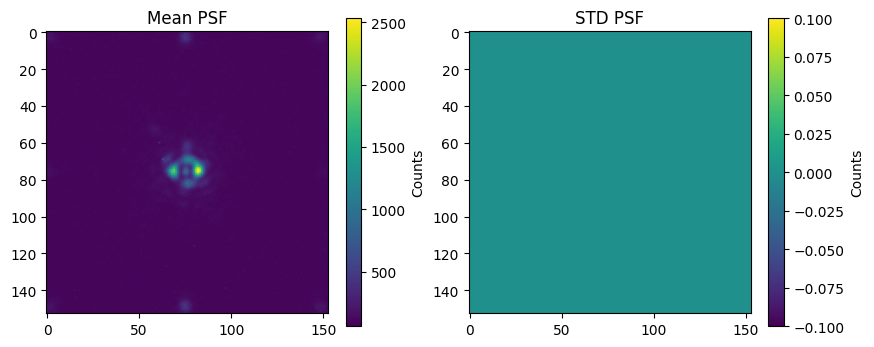

In [26]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.imshow(np.mean(test_croped, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('Mean PSF')

plt.subplot(1,2,2)
plt.imshow(np.std(test_croped, axis = 0), vmin =0)
plt.colorbar(label = 'Counts')
plt.title('STD PSF')

Text(0.5, 0.98, 'Numerical error')

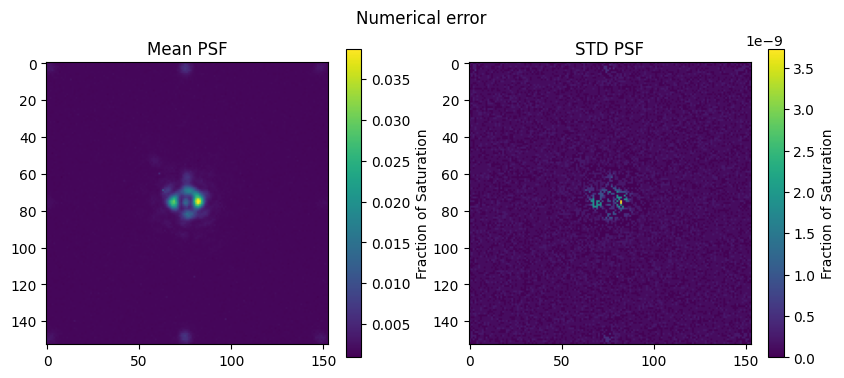

In [28]:
test_croped  = test_croped.astype(np.float32) / 65535

plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.imshow(np.mean(test_croped, axis = 0))
plt.colorbar(label = 'Fraction of Saturation')
plt.title('Mean PSF')

plt.subplot(1,2,2)
plt.imshow(np.std(test_croped, axis = 0), vmin =0)
plt.colorbar(label = 'Fraction of Saturation')
plt.title('STD PSF')

plt.suptitle('Numerical error')

# Pre-Processing of one stack

- Create master dark frame: median of 3500 dark frames of 25ms, in counts
- Center
- Crop
- Subtract df
- divide by 65535


In [2]:
radius = 55

In [4]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/darks/'
df = tiff.imread(glob.glob(f"{folder}df*.tif"))
#df  = df.astype(np.float32) #/ 65535
df = crop_stack(df, radius = radius)
master_df = np.median(df, axis = 0)
print(master_df.shape)

(111, 111)


In [7]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/new/7_17/coro_int_0.70ro_12.50ws_'
sci_img = tiff.imread(glob.glob(f"{folder}*.tif"), key=range(3500))
sci_img = crop_stack(sci_img,  radius = radius)
sci_img_processed = (sci_img - master_df) 
sci_img_processed  = sci_img_processed.astype(np.float32) / 65535
np.save(f'/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy', sci_img_processed.astype(np.float32))

folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/new/7_17/non_coro_int_0.70ro_12.50ws'
sci_img = tiff.imread(glob.glob(f"{folder}*.tif"), key=range(3500))
sci_img = crop_stack(sci_img,  radius = radius)
sci_img_processed = (sci_img - master_df) 
sci_img_processed  = sci_img_processed.astype(np.float32) / 65535
np.save(f'/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy', sci_img_processed.astype(np.float32))


print(sci_img_processed.shape)

(3500, 111, 111)


In [8]:
non_coro_int  = np.load('/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy')
non_coro_int = np.load('/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy')
print(non_coro_int.shape, non_coro_int.shape)

(3500, 111, 111) (3500, 111, 111)


Text(0.5, 1.0, 'Pre-Processed Mean Image')

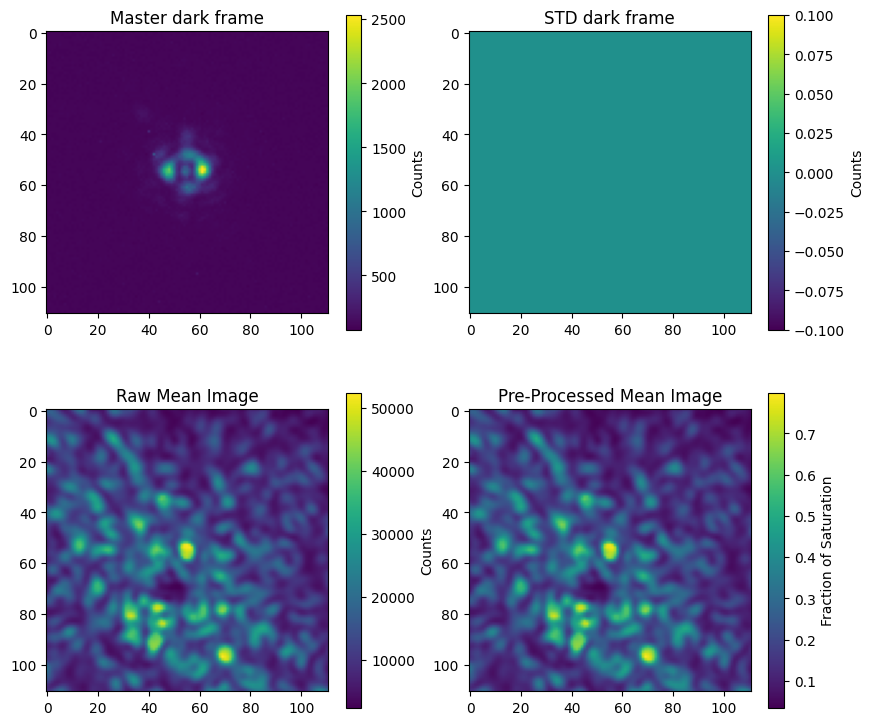

In [ ]:
plt.figure(figsize = (10,9))

plt.subplot(2,2,1)
plt.imshow(master_df)
plt.colorbar(label = 'Counts')
plt.title('Master median dark frame')

plt.subplot(2,2,2)
plt.imshow(np.std(df, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('STD dark frame')

plt.subplot(2,2,3)
plt.imshow(np.mean(sci_img, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('Raw Mean Image')

plt.subplot(2,2,4)
plt.imshow(np.mean(sci_img_processed, axis = 0))
plt.colorbar(label = 'Fraction of Saturation')
plt.title('Pre-Processed Mean Image')

# Speckle Diversity

# Test the Post-Processing algorithm 

I only have 3500 images per stack, I want to check if it affects anything.

In [9]:
dit_science = 11e-3  #s
dit_psf     = 0.590    #s
pixel_size  = None #arcsec
components  = [5, 20, 50, 100, 150] 

sc_img_int  = np.load('/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy')
# sc_img_pred = np.load('/home/aosimul/noah/data/ghost_images/25ms/int_test.npy')
# psf_pred    = np.load('/home/aosimul/noah/data/ghost_images/4ms/psf_pred.npy')
psf_int     = np.sum(np.load('/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy'), axis = 0)


In [10]:
# CREATE CURVES FROM CHECKPOINT DIR

datasets = {
    "int": {
        "psf"           : psf_int,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,            #s = 10 phase screens at 0.001s each
    },

    # "pred": {
    #     "psf"           : psf_pred,
    #     "fwhm"          : calculate_fwhm(psf_pred),
    #     "dit_psf"       : dit_psf,      #s of integration time
    #     "dit_science"   : dit_science,  
    # },
    
}

algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

grids = {}

#FILL
#-----------
name                    = 'new_test_grid' #'test_grid'
#-----------


for dataset_name, dataset in datasets.items():
    for algo_name, device in algorithms.items():
        #path = f"/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/{name}_{dataset_name}_{algo_name}"
        path = f"/home/aosimul/noah/results/contrast_grid/{name}_{dataset_name}_{algo_name}"
        path_ = root_dir / Path(path)
        print(str(path_))
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_template        =dataset["psf"],
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            checkpoint_dir      =root_dir / Path(path)
            )

        grids[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=None,  photometry = 'AS', test = 't-test', grid = True)
        
test_grid = grids.copy()

FWHM_x = 4.87 pix
FWHM_y = 4.84 pix
Mean FWHM = 4.86 pix 

/home/aosimul/noah/results/contrast_grid/new_test_grid_int_PCAD
Computing contrast grid for _PCA_005_components
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1469134) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


......................................................[DONE]
Computing contrast grid for _PCA_020_components
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1469134) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


......................................................[DONE]
Computing contrast grid for _PCA_050_components
.Computing contrast grid with multiprocessing:


...

......................................................[DONE]
Computing contrast grid for _PCA_150_components
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1469134) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


......................................................[DONE]
/home/aosimul/noah/results/contrast_grid/new_test_grid_int_CADI
Computing contrast grid for cADI
Computing contrast grid with multiprocessing:
.

/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1469134) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


......................................................[DONE]


In [11]:
def _save_grid_animation(contrast_grids, curves_output_path, dataset_name, algo_name):

    keys = list(contrast_grids.keys())

    fig = plt.figure(figsize=(7, 4))

    gs0 = fig.add_gridspec(1, 1)
    gs1 = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=gs0[0],
        wspace=0.05,
        width_ratios=[1, 0.03]
    )

    contrast_ax = fig.add_subplot(gs1[0])
    colorbar_ax = fig.add_subplot(gs1[1])


    def update(i):
        contrast_ax.clear()
        colorbar_ax.clear()

        key = keys[i]

        grid = contrast_grids[key].copy()

        # convert FPF to sigma
        grid = grid.map(fpf_2_gaussian_sigma)

        # convert flux ratio to magnitude
        grid.index = flux_ratio2mag(grid.index)

        plot_contrast_grid(
            contrast_grid_axis=contrast_ax,
            colorbar_axis=colorbar_ax,
            contrast_grid=grid,
            cmap = 'YlOrRd' if algo_name == 'CADI' else "YlGnBu"
        )

        contrast_ax.set_ylabel("Contrast - $c=f_p/f_*$ [mag]", fontsize=14)
        contrast_ax.set_xlabel("Separation [FWHM]", fontsize=14)

        contrast_ax.set_title(
            f"{dataset_name.replace("_", " ")}: {key.replace("_", " ")}",
            fontsize=16,
            fontweight="bold"
        )

        contrast_ax.tick_params(labelsize=12)
        plt.subplots_adjust(bottom=0.2)
        plt.close()

    ani = FuncAnimation(
        fig,
        update,
        frames=len(keys),
        interval=500
    )

    ani.save(f"{(curves_output_path)}/GRID_{dataset_name}_{algo_name}.gif", writer=PillowWriter(fps=1))

In [12]:
#curves_output_path = '/home/aosimul/noah/src/pipeline_ADI/results/contrast/pipeline_ADI_gram'
curves_output_path = '/home/aosimul/noah/results/animations'
for algo_name, device in algorithms.items():
    for dataset_name, dataset in datasets.items():
        contrast_curves_grid, contrast_grids = test_grid[(dataset_name,  algo_name)]
        _save_grid_animation(contrast_grids, curves_output_path, name+'_'+dataset_name, algo_name)

/home/aosimul/noah/notebooks/functions.py:1415: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl


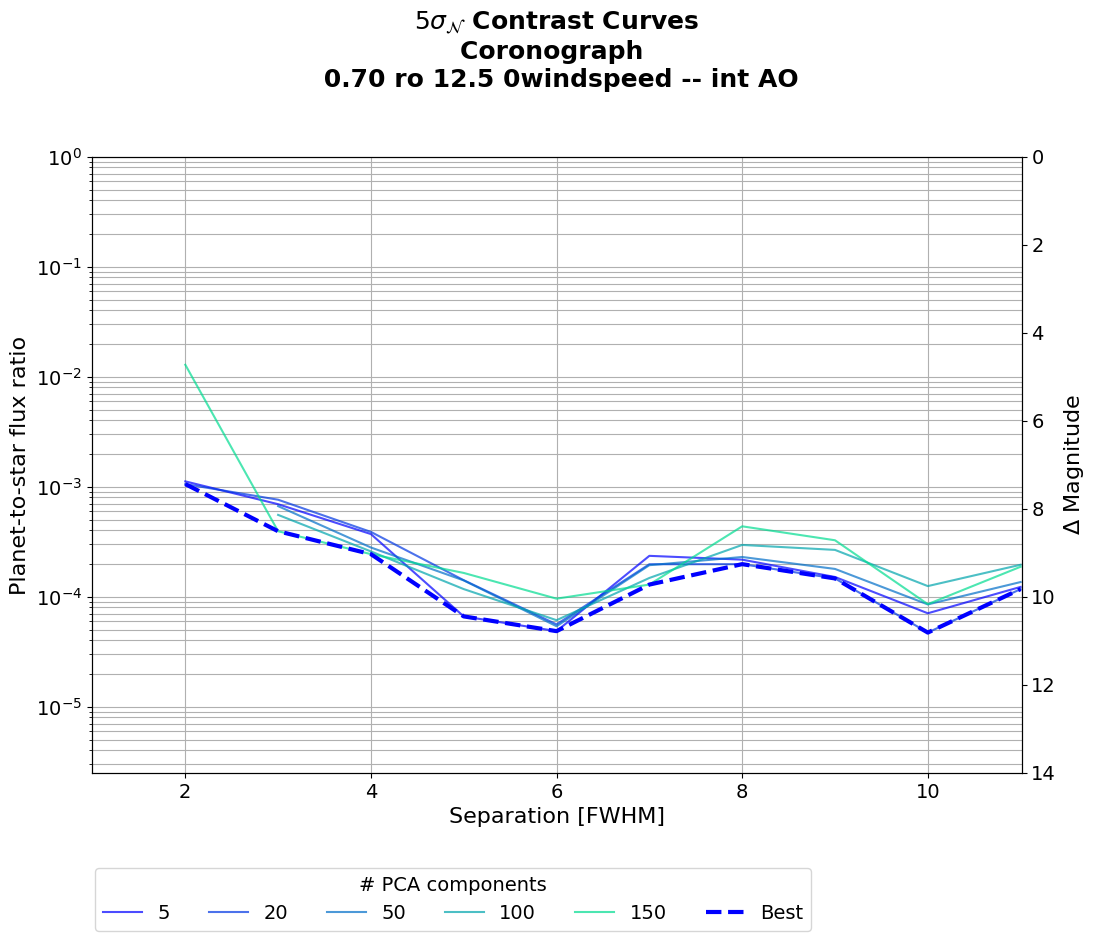

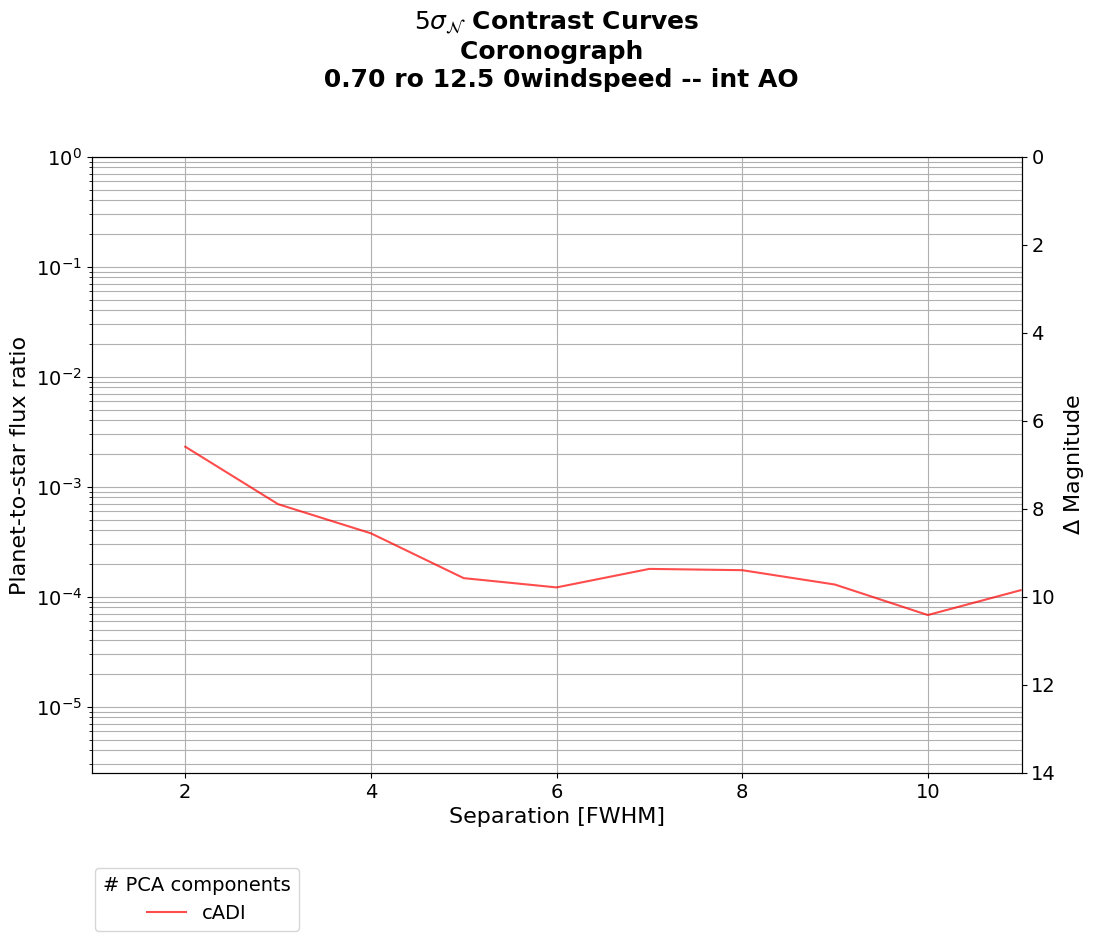

In [15]:
# MAKE PLOTS
curves_output_path = '/home/aosimul/noah/src/pipeline_ADI/results/contrast/pipeline_ADI_gram'
rangey      = (14, 0)
name = 'Coronograph \n 0.70 ro 12.5 0windspeed'
for algo_name, device in algorithms.items():
    for dataset_name, dataset in datasets.items():
        plot_contrast_curves2(test_grid[(dataset_name,  algo_name)][0], rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name} AO"))
        #plt.savefig(f'{curves_output_path}/{name}_{dataset_name}_{algo_name}.png', bbox_inches="tight", pad_inches=0.15)